**World Happiness Report**

Importing Libraries

In [17]:
# Data manipulation
import pandas as pd
import numpy as np

# Static plots
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive plots
import plotly.express as px
import plotly.graph_objects as go



Importing datasets

In [18]:
df2015=pd.read_csv("C:\\Users\\nancy\\Downloads\\sc4024 stuffs\\2015 (1).csv")
df2016=pd.read_csv("C:\\Users\\nancy\\Downloads\\sc4024 stuffs\\2016.csv")
df2017=pd.read_csv("C:\\Users\\nancy\\Downloads\\sc4024 stuffs\\2017 (1).csv")
df2018=pd.read_csv("C:\\Users\\nancy\\Downloads\\sc4024 stuffs\\2018.csv")
df2019=pd.read_csv("C:\\Users\\nancy\\Downloads\\sc4024 stuffs\\2019.csv")

In [19]:

# Add 'Year' column to each dataframe
df2015['Year'] = 2015
df2016['Year'] = 2016
df2017['Year'] = 2017
df2018['Year'] = 2018
df2019['Year'] = 2019

# Concatenate all dataframes into one
combined_df = pd.concat([df2015, df2016, df2017, df2018, df2019], ignore_index=True)

#Save to CSV
combined_df.to_csv("C:\\Users\\nancy\\Downloads\\combined_happiness_2015_2019.csv", index=False)

print("Dataframes concatenated successfully!")


Dataframes concatenated successfully!


In [20]:
# Use `melt` to convert to long format
df_long = pd.melt(combined_df,
                  id_vars=['Country or region', 'Year'],  # These stay fixed
                  value_vars=['Overall rank' ,'Score', 'GDP per capita', 'Social support', 
                              'Healthy life expectancy', 'Freedom to make life choices', 
                              'Generosity', 'Perceptions of corruption'],  # The columns to unpivot
                  var_name='Factor',  # The new column for the factor names
                  value_name='Value')  # The new column for values

# View the result
print(df_long)


# Optional: Save to CSV
df_long.to_csv("C:\\Users\\nancy\\Downloads\\long_format_happiness_2015_2019.csv", index=False)

print("Dataframe saved to long format CSV successfully!")


             Country or region  Year                     Factor  Value
0                  Switzerland  2015               Overall rank  1.000
1                      Iceland  2015               Overall rank  2.000
2                      Denmark  2015               Overall rank  3.000
3                       Norway  2015               Overall rank  4.000
4                       Canada  2015               Overall rank  5.000
...                        ...   ...                        ...    ...
6251                    Rwanda  2019  Perceptions of corruption  0.411
6252                  Tanzania  2019  Perceptions of corruption  0.147
6253               Afghanistan  2019  Perceptions of corruption  0.025
6254  Central African Republic  2019  Perceptions of corruption  0.035
6255               South Sudan  2019  Perceptions of corruption  0.091

[6256 rows x 4 columns]
Dataframe saved to long format CSV successfully!


C:\Users\nancy\AppData\Local\Temp\ipykernel_26064\589881198.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




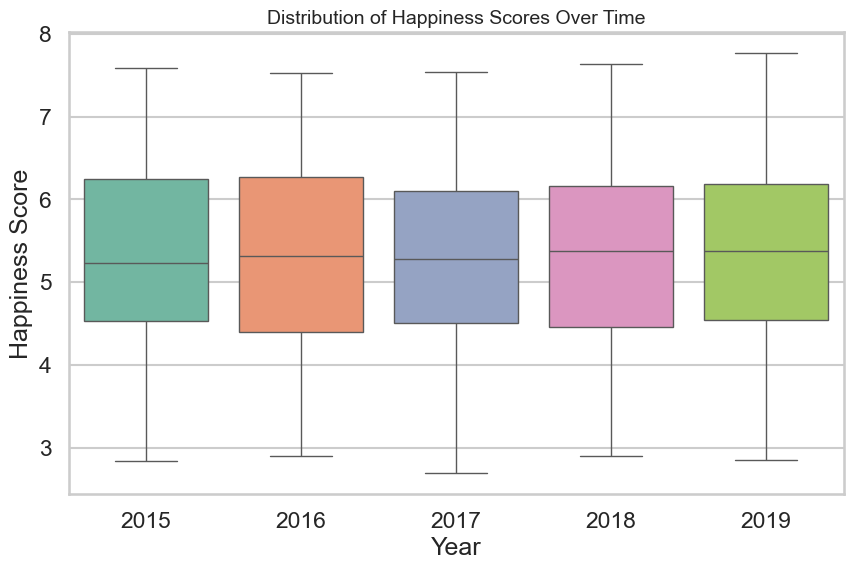

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x="Year", 
    y="Value", 
    data=df_long[df_long['Factor'] == 'Score'],
    palette="Set2"  # or "viridis", "pastel", "coolwarm"
)
plt.title("Distribution of Happiness Scores Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Happiness Score")
plt.show()

In [22]:
import plotly.express as px

fig = px.box(
    df_long[df_long['Factor'] == 'Score'],
    x="Year",
    y="Value",
    color="Year",  # gives per-year colors
    title="Distribution of Happiness Scores Over Time"
)
fig.update_layout(yaxis_title="Happiness Score")
fig.show()

In [23]:
import altair as alt
chart = (
    alt.Chart(df_long[df_long['Factor'] == 'Score'])
    .mark_boxplot()
    .encode(
        x='Year:O',
        y='Value:Q',
        color='Year:N',
        tooltip=['Year', 'Country or region', 'Value']
    )
    .properties(title='Distribution of Happiness Scores Over Time', width=600, height=400)
)
chart.interactive()


alt.Chart(...)

In [24]:
df = combined_df.copy()

# Quick inspection
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  782 non-null    int64  
 1   Country or region             782 non-null    object 
 2   Score                         782 non-null    float64
 3   GDP per capita                782 non-null    float64
 4   Social support                782 non-null    float64
 5   Healthy life expectancy       782 non-null    float64
 6   Freedom to make life choices  782 non-null    float64
 7   Generosity                    782 non-null    float64
 8   Perceptions of corruption     781 non-null    float64
 9   Year                          782 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 61.2+ KB


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,2,Iceland,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,3,Denmark,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,4,Norway,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,5,Canada,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


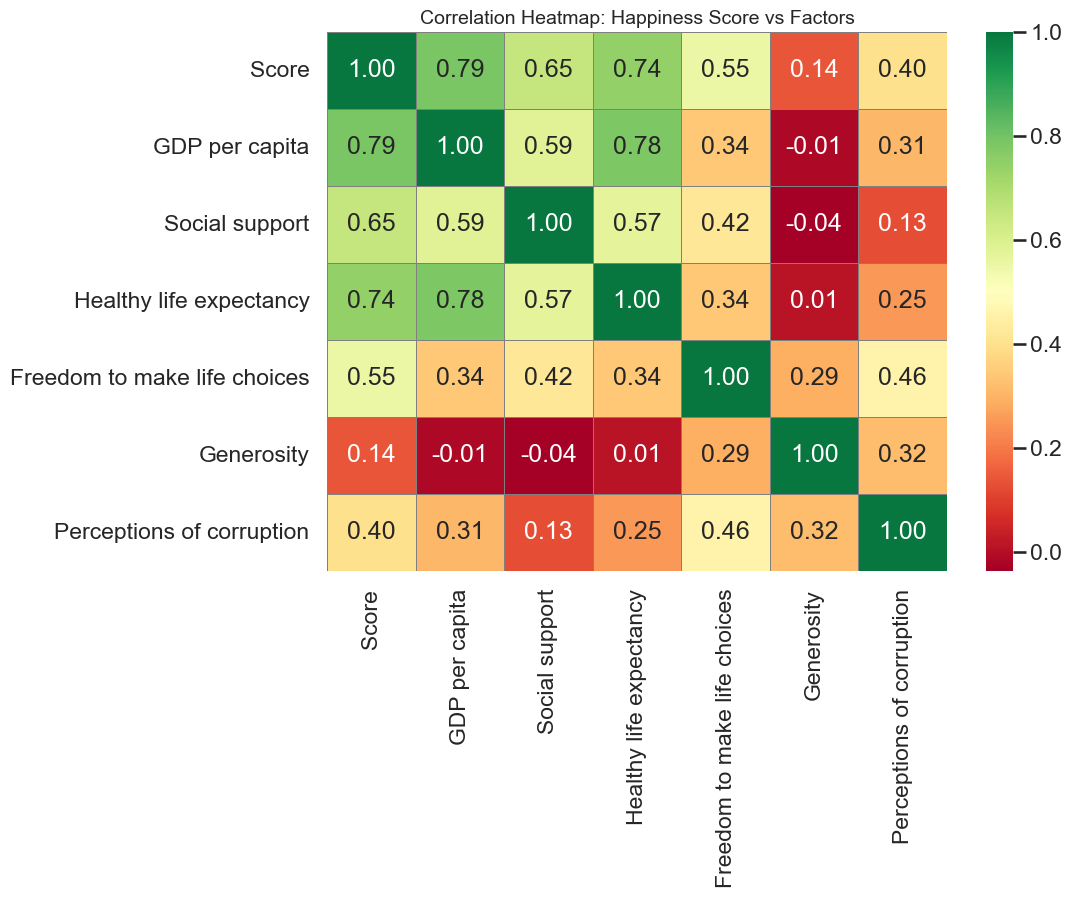

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
corr = df[['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
           'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']].corr()

#sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
#sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    center=0.5,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Correlation Heatmap: Happiness Score vs Factors", fontsize=14)
plt.show()


In [26]:
factors = [
    'GDP per capita', 'Social support', 'Healthy life expectancy',
    'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'
]

for factor in factors:
    corr = df['Score'].corr(df[factor])  # Pearson correlation by default
    print(f"{factor}: {corr:.3f}")


GDP per capita: 0.789
Social support: 0.649
Healthy life expectancy: 0.742
Freedom to make life choices: 0.551
Generosity: 0.138
Perceptions of corruption: 0.398


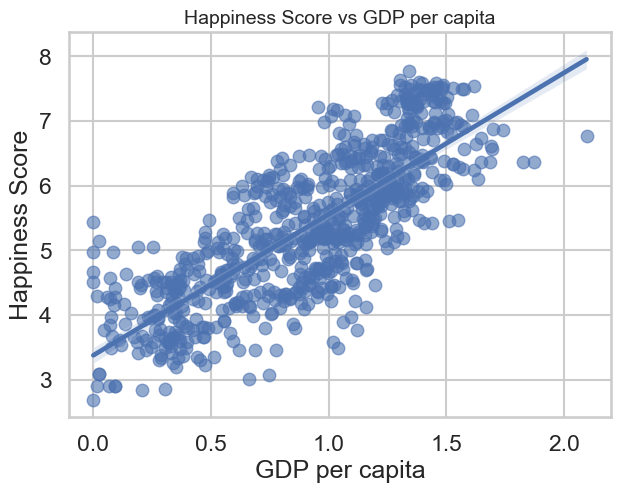

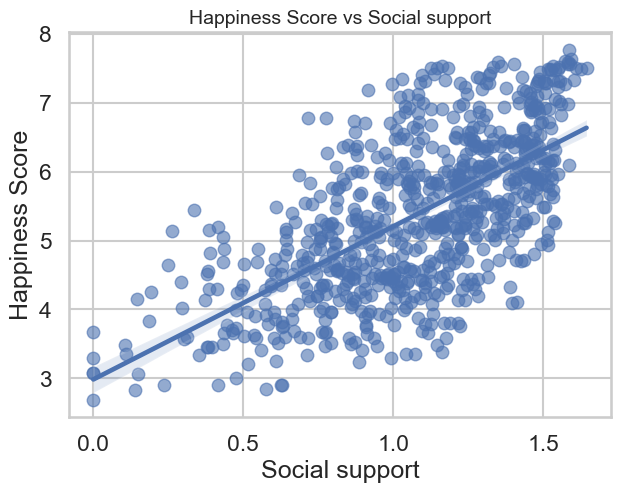

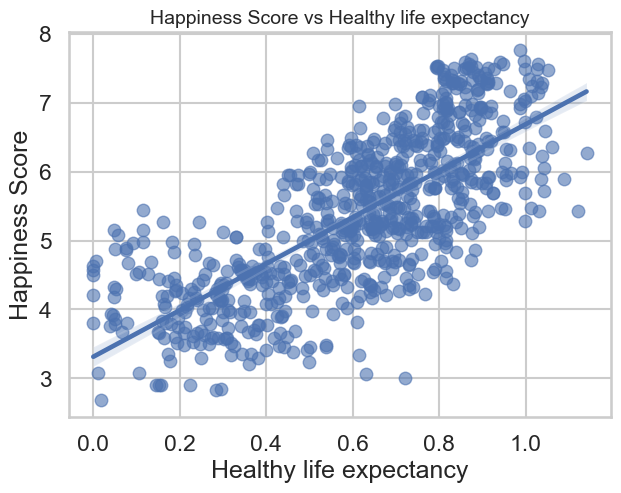

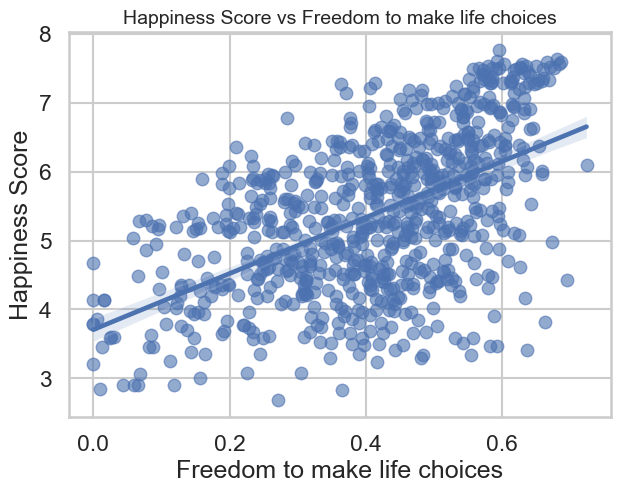

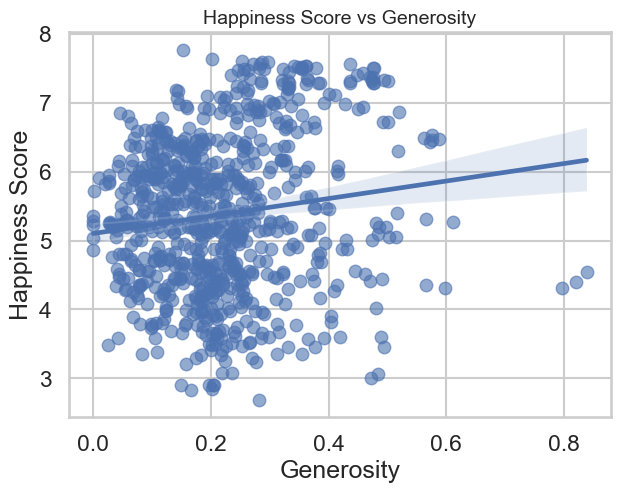

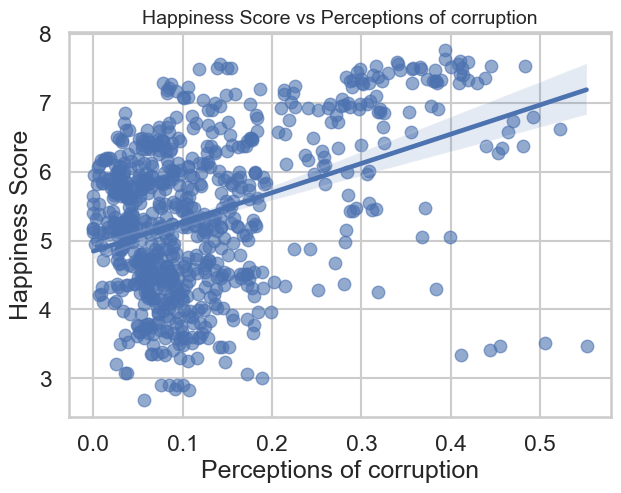

In [27]:
factors = [
    'GDP per capita', 'Social support', 'Healthy life expectancy',
    'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'
]

sns.set(style="whitegrid", context="talk")

for factor in factors:
    plt.figure(figsize=(7,5))
    sns.regplot(x=factor, y='Score', data=df, scatter_kws={'alpha':0.6})

    plt.title(f"Happiness Score vs {factor}", fontsize=14)
    plt.xlabel(factor)
    plt.ylabel("Happiness Score")
    plt.show()


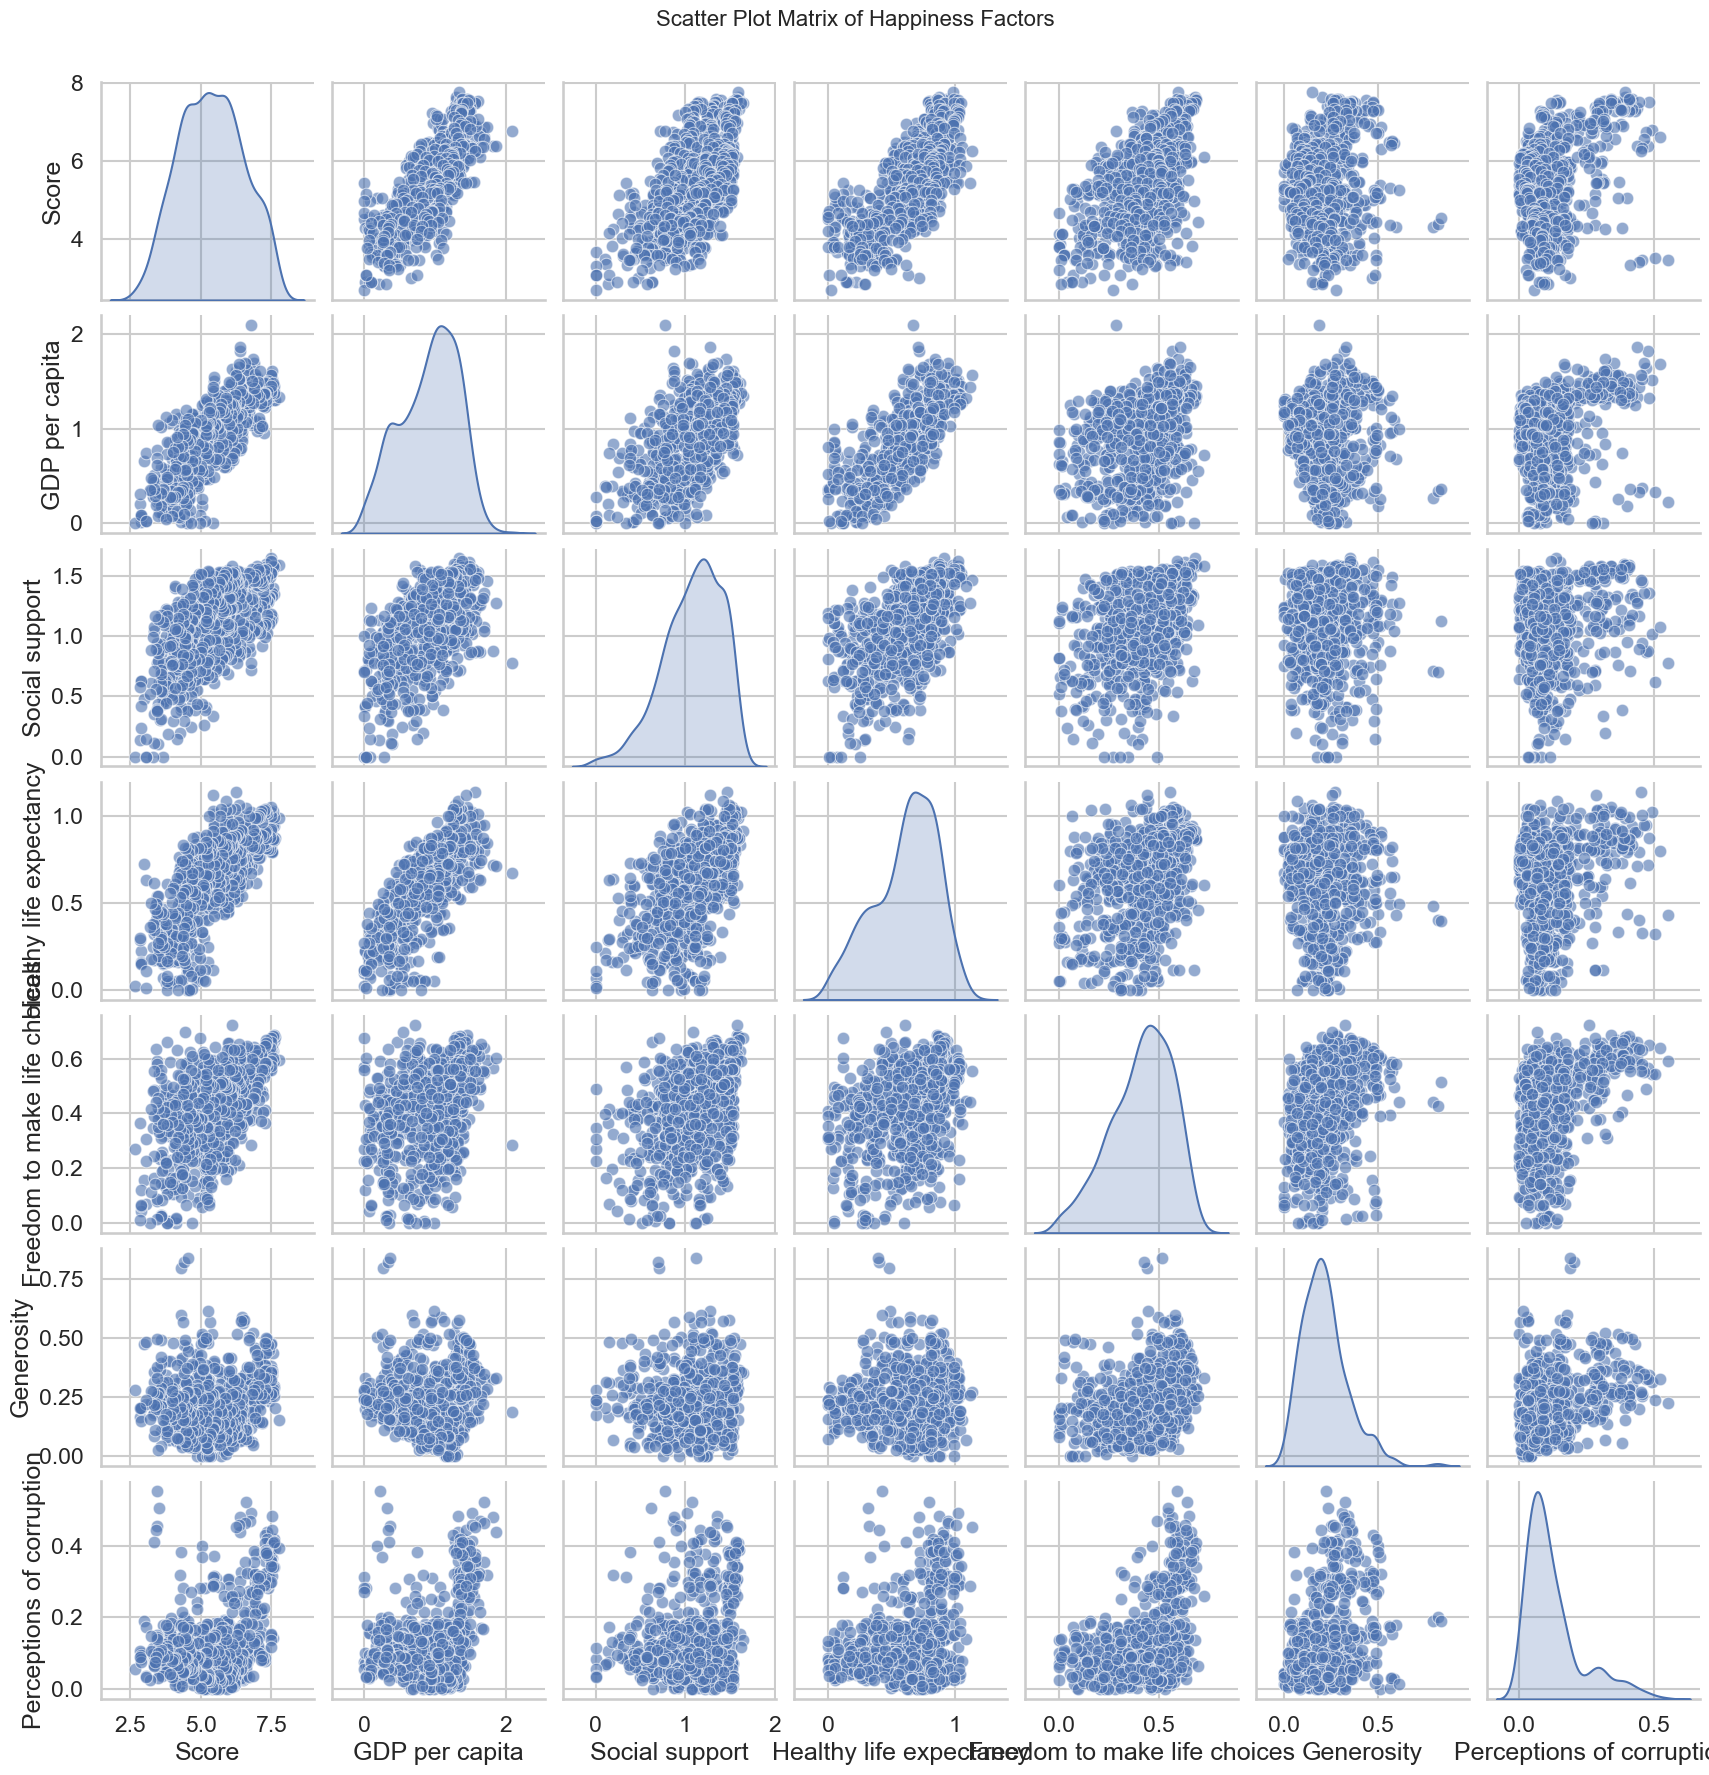

In [28]:
sns.pairplot(
    df[['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
        'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']],
    diag_kind='kde',
    plot_kws={'alpha':0.6}
    
)
plt.suptitle("Scatter Plot Matrix of Happiness Factors", y=1.02, fontsize=16)
plt.show()


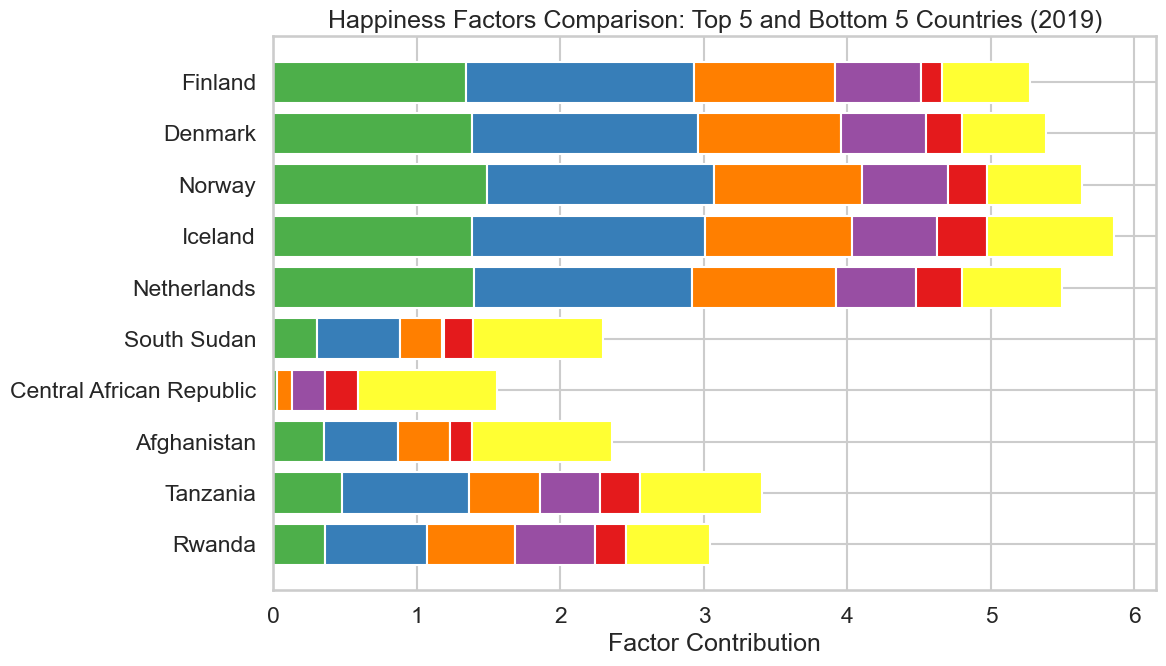

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter 2019 data
df_2019 = combined_df[combined_df['Year'] == 2019]

# Select top 5 happiest countries (lowest rank) and bottom 5 (highest rank)
top5 = df_2019.nsmallest(5, 'Overall rank')
bottom5 = df_2019.nlargest(5, 'Overall rank')

# Combine top5 and bottom5, but **stack top5 first, then bottom5**
compare_df = pd.concat([top5, bottom5])

# Factors to plot
factors = ['GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

# Optional: invert corruption if needed (so higher value = positive)
compare_df['Perceptions of corruption'] = 1 - compare_df['Perceptions of corruption']

# Set index to country for plotting
compare_df = compare_df.set_index('Country or region')

# Reorder index so top 5 are on top in the plot (horizontal bar plots show first index at bottom)
# So reverse the order to get top5 on top visually
compare_df = compare_df.iloc[::-1]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

bottom = pd.Series([0]*len(compare_df), index=compare_df.index)

colors = ['#4daf4a', '#377eb8', '#ff7f00', '#984ea3', '#e41a1c', '#ffff33']  # colors per factor

for idx, factor in enumerate(factors):
    ax.barh(compare_df.index, compare_df[factor], left=bottom, color=colors[idx], label=factor)
    bottom += compare_df[factor]

ax.set_xlabel('Factor Contribution')
ax.set_title('Happiness Factors Comparison: Top 5 and Bottom 5 Countries (2019)')
#ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [63]:
import pandas as pd
import plotly.graph_objects as go

# --- Load dataset ---
combined_df = pd.read_csv("C:\\Users\\nancy\\Downloads\\2019_modified.csv")

# --- Rename columns ---
combined_df = combined_df.rename(columns={
    'Country or region': 'Country',
    'Freedom to make life choices': 'Freedom',
    'Health (Life Expectancy)': 'Healthy life expectancy',
    'Economy (GDP per Capita)': 'GDP per capita',
    'Trust (Government Corruption)': 'Perceptions of corruption'
})

# --- Select countries ---
countries = ['Finland', 'Denmark', 'Norway', 'Iceland', 'Netherlands', 'Switzerland']
df_selected = combined_df[combined_df['Country'].isin(countries)]

# --- Relevant columns ---
cols = ['GDP per capita', 'Social support', 'Healthy life expectancy',
        'Freedom', 'Generosity', 'Perceptions of corruption']

# --- Convert and clean ---
for c in cols:
    df_selected[c] = pd.to_numeric(df_selected[c], errors='coerce')
df_selected = df_selected.dropna(subset=cols)

# --- Normalize (0–1 scale) ---
global_min = combined_df[cols].min()
global_max = combined_df[cols].max()
normalized = (df_selected.set_index('Country')[cols] - global_min) / (global_max - global_min)

# --- Radar setup ---
factors = normalized.columns.tolist()
colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#1f78b4']

fig = go.Figure()

for i, country in enumerate(normalized.index):
    line_width = 3 if country == "Finland" else 2
    fig.add_trace(go.Scatterpolar(
        r=normalized.loc[country].tolist() + [normalized.loc[country].tolist()[0]],
        theta=factors + [factors[0]],
        fill='toself',
        name=country,
        line=dict(color=colors[i % len(colors)], width=line_width),
        opacity=0.5,
        hovertemplate=(
            '<b>Country:</b> ' + country + '<br>' +
            '<b>%{theta}</b>: %{r:.2f}<extra></extra>'
        )
    ))

fig.update_layout(
    title=dict(
        text='<b>Comparison of Happiness Factors - Top 6 Countries (2019)</b>',
        x=0.5,
        font=dict(size=20, family='Arial Black', color='#222')
    ),
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            gridcolor='lightgray',
            tickfont=dict(size=13, color='#222', family='Arial Black')  # bold font
        ),
        angularaxis=dict(
            tickfont=dict(size=14, color='#111', family='Arial Black')  # bold font
        )
    ),
    legend=dict(
        title=dict(
            text='<b>Countries</b>',
            font=dict(size=14, color='#111', family='Arial Black')
        ),
        font=dict(size=13, color='#111', family='Arial Black'),  # bold font for legend items
        orientation='v',          # vertical legend
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='lightgray',
        borderwidth=1,
        x=1.05,                   # position to the right
        y=0.95,
        xanchor='left',
        yanchor='top'
    ),
    margin=dict(l=60, r=180, t=100, b=100),  # extra space for right-side legend
    template='plotly_white',
    height=700,
    width=950
)


fig.show()


C:\Users\nancy\AppData\Local\Temp\ipykernel_26064\3002940120.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

